Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import sys
from pathlib import Path

# Add the parent directory to sys.path
parent_path = Path().resolve().parent
if str(parent_path) not in sys.path:
    sys.path.append(str(parent_path))

In [2]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pytensor.tensor as pt
import pymc as pm
from scipy.stats import norm
from pathlib import Path
from models.utils import extract_psychometric, cumulative_normal

plt.rcParams["figure.constrained_layout.use"] = True

In [3]:
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
hrd_df = hrd_df[
    ((hrd_df.cohort == "vmp1") & (hrd_df.task == "hrd-session2"))
    | ((hrd_df.cohort == "vmp2") & (hrd_df.task == "hrd-session1"))
]

In [4]:
one_participant_df = hrd_df[
    (hrd_df.participant_id == "sub-0019") & (hrd_df.Modality == "Intero")
]

# Cardiac beliefs

In [5]:
# split the dataset into subject-wise low, medium and high cardiac frequencies
lowBPM_df, mediumBPM_df, highBPM_df = (
    pd.DataFrame([]),
    pd.DataFrame([]),
    pd.DataFrame([]),
)
for sub in hrd_df.participant_id.unique():
    this_df = hrd_df[(hrd_df.participant_id == sub) & (hrd_df.Modality == "Intero")]

    first, second = this_df.listenBPM.quantile(0.33), this_df.listenBPM.quantile(0.66)

    lowBPM_df = pd.concat([lowBPM_df, this_df[this_df.listenBPM <= first]])
    mediumBPM_df = pd.concat(
        [
            mediumBPM_df,
            this_df[(this_df.listenBPM > first) & (this_df.listenBPM <= second)],
        ]
    )
    highBPM_df = pd.concat([highBPM_df, this_df[this_df.listenBPM > second]])

In [39]:
def split_fit(df):

    #df = highBPM_df[highBPM_df.participant_id.isin(highBPM_df.participant_id.unique()[:50])]
    nsub = df.participant_id.nunique()
    participant_codes = pd.Categorical(df.participant_id).codes
    intero_decision = (
        df.Decision.to_numpy() == "More"
    ).astype(int)

    with pm.Model() as psychopysics:
    
        # heart rate -----------------------------------------------------
        mu_hr = pm.Normal("mu_hr", mu=60.0, sigma=30.0)
        sigma_hr = pm.HalfNormal("sigma_hr", sigma=30.0)
        
        std_hr = pm.Uniform("std_hr", 0.1, 40.0, shape=nsub)
        mean_hr = pm.Normal("mean_hr", mu=mu_hr, sigma=sigma_hr, shape=nsub)
        heart_rate = pm.Normal(
            "heart_rate",
            mu=mean_hr[participant_codes],
            sigma=std_hr[participant_codes],
            observed=df.listenBPM.to_numpy(),
        )
    
        # cardiac beliefs -------------------------------------------------
        mu_belief = pm.Normal("mu_belief", mu=60.0, sigma=30.0)
        sigma_belief = pm.HalfNormal("sigma_belief", sigma=30.0)
    
        belief_mean = pm.Normal("belief_mean", mu=mu_belief, sigma=sigma_belief, shape=nsub)
        belief_std = pm.Uniform("belief_std", lower=0.1, upper=50, shape=nsub)
    
        theta_belief = pm.Deterministic(
            "theta_belief", cumulative_normal(df.responseBPM.to_numpy(), belief_mean[participant_codes], belief_std[participant_codes])
        )
        _ = pm.Binomial("rij_beliefs", p=theta_belief, n=1, observed=intero_decision)
    
        idata = pm.sample(
            chains=4, cores=4, tune=1000, draws=1000, return_inferencedata=True, nuts_sampler="nutpie",
        )
    
    return idata

In [40]:
idata_low = split_fit(lowBPM_df)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,53,0.13,31
,2000,41,0.13,31
,2000,53,0.14,31
,2000,73,0.13,31


In [41]:
idata_medium = split_fit(mediumBPM_df)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,119,0.12,31
,2000,84,0.12,31
,2000,58,0.12,31
,2000,119,0.12,31


In [42]:
idata_high = split_fit(highBPM_df)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,164,0.13,31
,2000,74,0.13,31
,2000,56,0.13,31
,2000,48,0.13,31


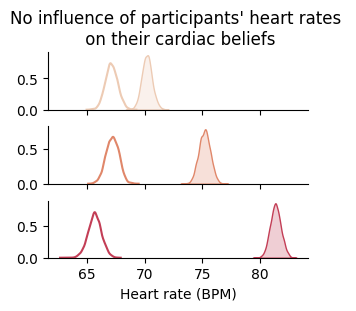

In [84]:
_, axs = plt.subplots(figsize=(3, 3), nrows=3, ncols=1, sharex="col")

for idx, idata, color in zip(
    range(3), [idata_low, idata_medium, idata_high], ["#edcbb4", "#e0876a", "#c33e56"]
):
    posterior = (idata.posterior["mu_hr"]).values.flatten()
    sns.kdeplot(posterior, ax=axs[idx], color=color, fill=True)

    posterior = (idata.posterior["mu_belief"]).values.flatten()
    sns.kdeplot(posterior, ax=axs[idx], color=color)

axs[0].set(ylabel=None, title="No influence of participants' heart rates \n on their cardiac beliefs")
axs[1].set(ylabel=None)
axs[2].set(xlabel="Heart rate (BPM)", ylabel=None)

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_2_splits.svg")